# 06 — Airline & Airport Clustering

K-Means segmentation of 15 airlines into 5 clusters and 360 airports into 4 clusters. Cluster labels are added as categorical features to improve model performance.

**Input:** `dataset/merged_flights_fe.parquet`

**Output:** `dataset/merged_flights_fe.parquet` (updated with `airline_cluster_label`, `airport_cluster_label`)

**Clusters:**
- Mainline (K=3): Financially Strong · Financially Stressed High Delay · Cascade Heavy
- Regional (K=2): Reliable Regionals · Mid-Tier Regionals
- Airports (K=4): Major Hubs · Mid-Size Moderate · Efficient Airports · Small Chronic Delay

In [1]:
import pandas as pd


In [2]:
flights=pd.read_parquet("/Users/harshithnr/flight_delay_predictions/dataset/merged_flights_fe.parquet")

## Airline Profiling
Aggregate delay rate, profit margin, cascade score, and cost efficiency per carrier.

In [3]:
airline_profile = flights.groupby('OP_UNIQUE_CARRIER').agg(
    airline_name=('AIRLINE_NAME', 'first'),
    flight_count=('ARR_DEL15', 'count'),
    actual_delay_rate=('ARR_DEL15', 'mean'),
    profit_margin=('profit_margin', 'mean'),
    cost_efficiency=('cost_efficiency', 'mean'),
    airline_delay_rate_30d=('airline_delay_rate_30d', 'mean'),
    cascade_score=('cascade_score', 'mean'),
).round(4)

print(airline_profile.sort_values('actual_delay_rate', ascending=False).to_string())

                        airline_name  flight_count  actual_delay_rate  profit_margin  cost_efficiency  airline_delay_rate_30d  cascade_score
OP_UNIQUE_CARRIER                                                                                                                           
F9                          Frontier        504061             0.2991        -0.0068           1.0068                  0.2954         0.2238
B6                           JetBlue        654301             0.2789        -0.0992           1.0992                  0.2796         0.1760
NK                            Spirit        651621             0.2544        -0.1708           1.1708                  0.2538         0.1835
AA                 American Airlines       2520340             0.2514         0.0668           0.9332                  0.2509         0.1643
G4                         Allegiant        319584             0.2427         0.0695           0.9305                  0.2237         0.1927
OH           

In [4]:
regionals = ['9E', 'MQ', 'OH', 'YX', 'OO']
mainline = flights[~flights['OP_UNIQUE_CARRIER'].isin(regionals)]

mainline_profile = mainline.groupby('OP_UNIQUE_CARRIER').agg(
    airline_name=('AIRLINE_NAME', 'first'),
    flight_count=('ARR_DEL15', 'count'),
    actual_delay_rate=('ARR_DEL15', 'mean'),
    profit_margin=('profit_margin', 'mean'),
    cost_efficiency=('cost_efficiency', 'mean'),
    airline_delay_rate_30d=('airline_delay_rate_30d', 'mean'),
    cascade_score=('cascade_score', 'mean'),
).round(4)

print(mainline_profile.sort_values('actual_delay_rate', ascending=False).to_string())
print(f"\nRegional → Parent mapping:")
print("  9E (Endeavor) → DL (Delta)")
print("  MQ (Envoy) → AA (American)")  
print("  OH (PSA) → AA (American)")
print("  YX (Republic) → multiple, primarily DL/AA/UA")
print("  OO (SkyWest) → multiple, primarily DL/UA/AA")

                        airline_name  flight_count  actual_delay_rate  profit_margin  cost_efficiency  airline_delay_rate_30d  cascade_score
OP_UNIQUE_CARRIER                                                                                                                           
F9                          Frontier        504061             0.2991        -0.0068           1.0068                  0.2954         0.2238
B6                           JetBlue        654301             0.2789        -0.0992           1.0992                  0.2796         0.1760
NK                            Spirit        651621             0.2544        -0.1708           1.1708                  0.2538         0.1835
AA                 American Airlines       2520340             0.2514         0.0668           0.9332                  0.2509         0.1643
G4                         Allegiant        319584             0.2427         0.0695           0.9305                  0.2237         0.1927
AS           

In [5]:
print("Republic (YX) operates as:")
print(flights[flights['OP_UNIQUE_CARRIER']=='YX']['AIRLINE_NAME'].value_counts())

print("\nSkyWest (OO) operates as:")
print(flights[flights['OP_UNIQUE_CARRIER']=='OO']['AIRLINE_NAME'].value_counts())

Republic (YX) operates as:
AIRLINE_NAME
Republic Airways    797641
Name: count, dtype: int64

SkyWest (OO) operates as:
AIRLINE_NAME
SkyWest    1941985
Name: count, dtype: int64


## Mainline Airline Clustering (K=3)
K-Means on 4 features: profit_margin, cost_efficiency, airline_delay_rate_30d, cascade_score.

=== MAINLINE PROFILES ===
                   profit_margin  cost_efficiency  airline_delay_rate_30d  cascade_score
OP_UNIQUE_CARRIER                                                                       
F9                       -0.0068           1.0068                  0.2954         0.2238
B6                       -0.0992           1.0992                  0.2796         0.1760
NK                       -0.1708           1.1708                  0.2538         0.1835
AA                        0.0668           0.9332                  0.2509         0.1643
G4                        0.0695           0.9305                  0.2237         0.1927
AS                        0.0528           0.9472                  0.2161         0.1223
WN                        0.0063           0.9937                  0.2113         0.2069
UA                        0.0792           0.9208                  0.2085         0.1154
HA                       -0.0617           1.0617                  0.1905         0.

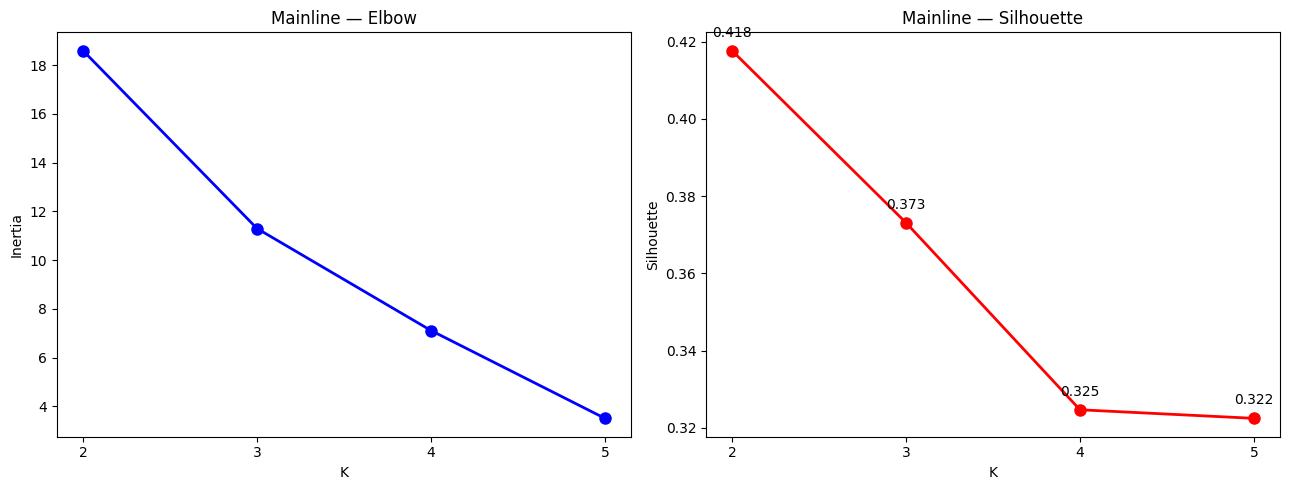

K=2: silhouette=0.4176
K=3: silhouette=0.3731
K=4: silhouette=0.3247
K=5: silhouette=0.3225


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

mainline_carriers = ['AA', 'AS', 'B6', 'DL', 'F9', 'G4', 'HA', 'NK', 'UA', 'WN']
mainline_features = ['profit_margin', 'cost_efficiency', 'airline_delay_rate_30d', 'cascade_score']

mainline_agg = flights[flights['OP_UNIQUE_CARRIER'].isin(mainline_carriers)] \
    .groupby('OP_UNIQUE_CARRIER')[mainline_features].mean()

print("=== MAINLINE PROFILES ===")
print(mainline_agg.round(4).sort_values('airline_delay_rate_30d', ascending=False).to_string())

scaler = StandardScaler()
X = scaler.fit_transform(mainline_agg)

K_range = range(2, 6)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia'); ax1.set_title('Mainline — Elbow')
ax1.set_xticks(list(K_range))
ax2.plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette'); ax2.set_title('Mainline — Silhouette')
ax2.set_xticks(list(K_range))
for k, s in zip(K_range, silhouettes):
    ax2.annotate(f'{s:.3f}', (k, s), textcoords="offset points", xytext=(0, 10), ha='center')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"K={k}: silhouette={s:.4f}")

## Optimal K Selection
Evaluate silhouette, Calinski-Harabasz, and Davies-Bouldin scores for K=2 to 5.

In [7]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

K_range = range(2, 6)

print(f"{'K':<5} {'Silhouette':<15} {'Calinski-Harabasz':<20} {'Davies-Bouldin':<15}")
print("-" * 55)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"{k:<5} {sil:<15.4f} {ch:<20.4f} {db:<15.4f}")

print("\nHow to read:")
print("  Silhouette:        higher = better (max 1.0)")
print("  Calinski-Harabasz: higher = better (dense, well-separated clusters)")
print("  Davies-Bouldin:    lower = better (less overlap between clusters)")

K     Silhouette      Calinski-Harabasz    Davies-Bouldin 
-------------------------------------------------------
2     0.4176          9.2100               0.8998         
3     0.3731          8.8932               0.8092         
4     0.3247          9.2500               0.6383         
5     0.3225          13.0099              0.5072         

How to read:
  Silhouette:        higher = better (max 1.0)
  Calinski-Harabasz: higher = better (dense, well-separated clusters)
  Davies-Bouldin:    lower = better (less overlap between clusters)


In [8]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X)
    
    print(f"\n{'='*60}")
    print(f"K={k}")
    print(f"{'='*60}")
    
    for c in sorted(set(labels)):
        carriers = mainline_agg.index[labels == c].tolist()
        subset = mainline_agg.loc[carriers]
        names = [flights[flights['OP_UNIQUE_CARRIER']==cr]['AIRLINE_NAME'].iloc[0] for cr in carriers]
        print(f"\n  Cluster {c}: {', '.join(names)}")
        print(f"    profit_margin:          {subset['profit_margin'].mean():.4f}")
        print(f"    cost_efficiency:        {subset['cost_efficiency'].mean():.4f}")
        print(f"    airline_delay_rate_30d: {subset['airline_delay_rate_30d'].mean():.4f}")
        print(f"    cascade_score:          {subset['cascade_score'].mean():.4f}")


K=3

  Cluster 0: American Airlines, Alaska Airlines, Delta, Allegiant, United
    profit_margin:          0.0713
    cost_efficiency:        0.9287
    airline_delay_rate_30d: 0.2159
    cascade_score:          0.1434

  Cluster 1: JetBlue, Frontier, Spirit
    profit_margin:          -0.0923
    cost_efficiency:        1.0923
    airline_delay_rate_30d: 0.2763
    cascade_score:          0.1944

  Cluster 2: Hawaiian, Southwest
    profit_margin:          -0.0277
    cost_efficiency:        1.0277
    airline_delay_rate_30d: 0.2009
    cascade_score:          0.2510

K=4

  Cluster 0: American Airlines, Frontier, Allegiant, Southwest
    profit_margin:          0.0339
    cost_efficiency:        0.9661
    airline_delay_rate_30d: 0.2453
    cascade_score:          0.1969

  Cluster 1: JetBlue, Spirit
    profit_margin:          -0.1350
    cost_efficiency:        1.1350
    airline_delay_rate_30d: 0.2667
    cascade_score:          0.1798

  Cluster 2: Alaska Airlines, Delta, United

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

print("=== DBSCAN on Mainline Airlines (10 points, 4 features) ===\n")

for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]:
    db = DBSCAN(eps=eps, min_samples=2)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels) - {-1})
    n_noise = (labels == -1).sum()
    
    sil = silhouette_score(X, labels) if n_clusters >= 2 and n_noise < len(labels) - 1 else None
    sil_str = f"{sil:.4f}" if sil else "N/A"
    
    carriers_by_cluster = {}
    for carrier, label in zip(mainline_agg.index, labels):
        carriers_by_cluster.setdefault(label, []).append(carrier)
    
    print(f"eps={eps:.1f} | clusters={n_clusters} | noise={n_noise} | silhouette={sil_str}")
    for c in sorted(carriers_by_cluster):
        tag = "NOISE" if c == -1 else f"Cluster {c}"
        print(f"    {tag}: {', '.join(carriers_by_cluster[c])}")
    print()

=== DBSCAN on Mainline Airlines (10 points, 4 features) ===

eps=0.5 | clusters=0 | noise=10 | silhouette=N/A
    NOISE: AA, AS, B6, DL, F9, G4, HA, NK, UA, WN

eps=0.8 | clusters=1 | noise=8 | silhouette=N/A
    NOISE: AA, B6, DL, F9, G4, HA, NK, WN
    Cluster 0: AS, UA

eps=1.0 | clusters=2 | noise=5 | silhouette=0.2363
    NOISE: B6, F9, HA, NK, WN
    Cluster 0: AA, G4
    Cluster 1: AS, DL, UA

eps=1.2 | clusters=2 | noise=4 | silhouette=0.2714
    NOISE: B6, F9, HA, NK
    Cluster 0: AA, G4, WN
    Cluster 1: AS, DL, UA

eps=1.5 | clusters=2 | noise=2 | silhouette=0.3853
    NOISE: F9, HA
    Cluster 0: AA, AS, DL, G4, UA, WN
    Cluster 1: B6, NK

eps=2.0 | clusters=2 | noise=1 | silhouette=0.4104
    NOISE: HA
    Cluster 0: AA, AS, DL, G4, UA, WN
    Cluster 1: B6, F9, NK

eps=2.5 | clusters=1 | noise=0 | silhouette=N/A
    Cluster 0: AA, AS, B6, DL, F9, G4, HA, NK, UA, WN



In [10]:
km_main = KMeans(n_clusters=3, n_init=50, random_state=42)
mainline_agg['cluster'] = km_main.fit_predict(X)

mainline_cluster_names = {}
for c in sorted(mainline_agg['cluster'].unique()):
    subset = mainline_agg[mainline_agg['cluster'] == c]
    carriers = subset.index.tolist()
    pm = subset['profit_margin'].mean()
    dr = subset['airline_delay_rate_30d'].mean()
    cs = subset['cascade_score'].mean()
    print(f"Cluster {c}: {carriers} | margin={pm:.3f} delay={dr:.3f} cascade={cs:.3f}")

print("\nAssign names based on output above.")
print("Expected mapping (verify cluster numbers match):")
print("  Profitable + low delay + low cascade → 'Financially Strong Operators'")
print("  Losing money + high delay            → 'Financially Stressed High Delay'") 
print("  Moderate delay + high cascade         → 'Cascade Heavy Operations'")

Cluster 0: ['AA', 'AS', 'DL', 'G4', 'UA'] | margin=0.071 delay=0.216 cascade=0.143
Cluster 1: ['B6', 'F9', 'NK'] | margin=-0.092 delay=0.276 cascade=0.194
Cluster 2: ['HA', 'WN'] | margin=-0.028 delay=0.201 cascade=0.251

Assign names based on output above.
Expected mapping (verify cluster numbers match):
  Profitable + low delay + low cascade → 'Financially Strong Operators'
  Losing money + high delay            → 'Financially Stressed High Delay'
  Moderate delay + high cascade         → 'Cascade Heavy Operations'


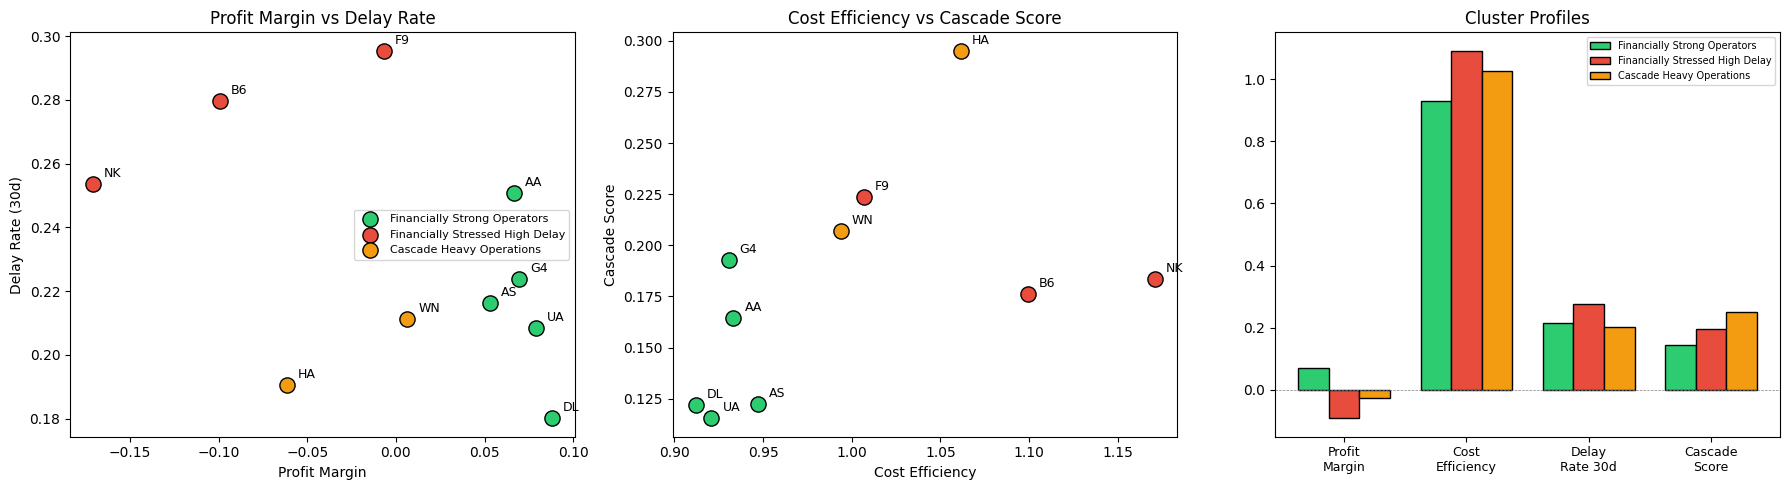

In [11]:
import matplotlib.pyplot as plt
import numpy as np

mainline_cluster_names = {
    0: 'Financially Strong Operators',
    1: 'Financially Stressed High Delay',
    2: 'Cascade Heavy Operations'
}

colors = {0: '#2ecc71', 1: '#e74c3c', 2: '#f39c12'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for c in [0, 1, 2]:
    subset = mainline_agg[mainline_agg['cluster'] == c]
    ax.scatter(subset['profit_margin'], subset['airline_delay_rate_30d'], 
               c=colors[c], s=120, label=mainline_cluster_names[c], edgecolors='black', zorder=3)
    for carrier in subset.index:
        ax.annotate(carrier, (subset.loc[carrier, 'profit_margin'], 
                    subset.loc[carrier, 'airline_delay_rate_30d']),
                    textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel('Profit Margin')
ax.set_ylabel('Delay Rate (30d)')
ax.set_title('Profit Margin vs Delay Rate')
ax.legend(fontsize=8)

ax = axes[1]
for c in [0, 1, 2]:
    subset = mainline_agg[mainline_agg['cluster'] == c]
    ax.scatter(subset['cost_efficiency'], subset['cascade_score'],
               c=colors[c], s=120, label=mainline_cluster_names[c], edgecolors='black', zorder=3)
    for carrier in subset.index:
        ax.annotate(carrier, (subset.loc[carrier, 'cost_efficiency'],
                    subset.loc[carrier, 'cascade_score']),
                    textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel('Cost Efficiency')
ax.set_ylabel('Cascade Score')
ax.set_title('Cost Efficiency vs Cascade Score')

ax = axes[2]
features_to_plot = ['profit_margin', 'cost_efficiency', 'airline_delay_rate_30d', 'cascade_score']
x = np.arange(len(features_to_plot))
width = 0.25
for i, c in enumerate([0, 1, 2]):
    subset = mainline_agg[mainline_agg['cluster'] == c]
    vals = [subset[f].mean() for f in features_to_plot]
    ax.bar(x + i*width, vals, width, label=mainline_cluster_names[c], color=colors[c], edgecolor='black')
ax.set_xticks(x + width)
ax.set_xticklabels(['Profit\nMargin', 'Cost\nEfficiency', 'Delay\nRate 30d', 'Cascade\nScore'], fontsize=9)
ax.set_title('Cluster Profiles')
ax.legend(fontsize=7)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Regional Airline Clustering (K=2)
Smaller regional carriers clustered separately on delay rate and cascade score.

In [12]:
regional_carriers = ['9E', 'MQ', 'OH', 'YX', 'OO']
regional_features = ['airline_delay_rate_30d', 'cascade_score']

regional_agg = flights[flights['OP_UNIQUE_CARRIER'].isin(regional_carriers)] \
    .groupby('OP_UNIQUE_CARRIER')[regional_features].mean()

for carrier in regional_carriers:
    name = flights[flights['OP_UNIQUE_CARRIER']==carrier]['AIRLINE_NAME'].iloc[0]
    dr = flights[flights['OP_UNIQUE_CARRIER']==carrier]['ARR_DEL15'].mean()
    regional_agg.loc[carrier, 'airline_name'] = name
    regional_agg.loc[carrier, 'actual_delay_rate'] = dr

print("=== REGIONAL PROFILES ===")
print(regional_agg[['airline_name', 'airline_delay_rate_30d', 'cascade_score', 'actual_delay_rate']].to_string())

scaler_reg = StandardScaler()
X_reg = scaler_reg.fit_transform(regional_agg[regional_features])

km_reg = KMeans(n_clusters=2, n_init=50, random_state=42)
regional_agg['cluster'] = km_reg.fit_predict(X_reg)

print(f"\nSilhouette: {silhouette_score(X_reg, regional_agg['cluster']):.4f}")

for c in sorted(regional_agg['cluster'].unique()):
    subset = regional_agg[regional_agg['cluster'] == c]
    carriers = subset.index.tolist()
    print(f"\nCluster {c}: {carriers}")
    print(f"  delay_rate_30d: {subset['airline_delay_rate_30d'].mean():.4f}")
    print(f"  cascade_score:  {subset['cascade_score'].mean():.4f}")

=== REGIONAL PROFILES ===
                       airline_name  airline_delay_rate_30d  cascade_score  actual_delay_rate
OP_UNIQUE_CARRIER                                                                            
9E                     Endeavor Air                0.149635       0.148649           0.148695
MQ                        Envoy Air                0.204654       0.213017           0.202992
OH                     PSA Airlines                0.222575       0.241076           0.221430
OO                          SkyWest                0.187493       0.211216           0.187454
YX                 Republic Airways                0.157262       0.142198           0.154497

Silhouette: 0.7198

Cluster 0: ['MQ', 'OH', 'OO']
  delay_rate_30d: 0.2049
  cascade_score:  0.2218

Cluster 1: ['9E', 'YX']
  delay_rate_30d: 0.1534
  cascade_score:  0.1454


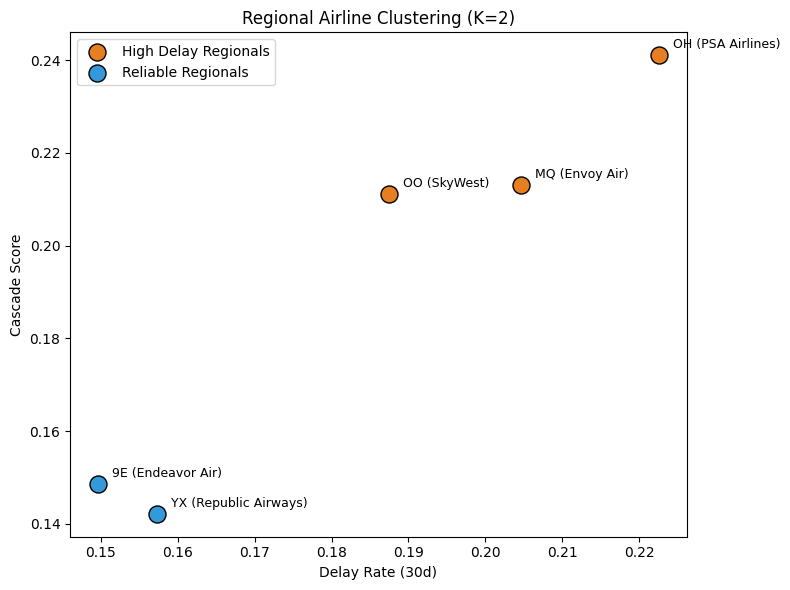

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

reg_colors = {0: '#e67e22', 1: '#3498db'}
reg_names = {0: 'High Delay Regionals', 1: 'Reliable Regionals'}

for c in [0, 1]:
    subset = regional_agg[regional_agg['cluster'] == c]
    ax.scatter(subset['airline_delay_rate_30d'], subset['cascade_score'],
               c=reg_colors[c], s=150, label=reg_names[c], edgecolors='black', zorder=3)
    for carrier in subset.index:
        name = subset.loc[carrier, 'airline_name']
        ax.annotate(f"{carrier} ({name})", 
                    (subset.loc[carrier, 'airline_delay_rate_30d'],
                     subset.loc[carrier, 'cascade_score']),
                    textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_xlabel('Delay Rate (30d)')
ax.set_ylabel('Cascade Score')
ax.set_title('Regional Airline Clustering (K=2)')
ax.legend()
plt.tight_layout()
plt.show()

## Build Final Airline Cluster Mapping

In [14]:
mainline_cluster_names = {
    0: 'Financially Strong Operators',
    1: 'Financially Stressed High Delay',
    2: 'Cascade Heavy Operations'
}
regional_cluster_names = {
    0: 'High Delay Regionals',
    1: 'Reliable Regionals'
}

airline_label_map = {}

for carrier in mainline_agg.index:
    c = mainline_agg.loc[carrier, 'cluster']
    airline_label_map[carrier] = mainline_cluster_names[c]

for carrier in regional_agg.index:
    c = regional_agg.loc[carrier, 'cluster']
    airline_label_map[carrier] = regional_cluster_names[c]

print("Full mapping:")
for carrier, label in sorted(airline_label_map.items()):
    name = flights[flights['OP_UNIQUE_CARRIER']==carrier]['AIRLINE_NAME'].iloc[0]
    print(f"  {carrier} ({name}): {label}")

flights['airline_cluster_label'] = flights['OP_UNIQUE_CARRIER'].map(airline_label_map)

print(f"\nNulls: {flights['airline_cluster_label'].isna().sum()}")
print(f"\nDistribution:")
print(flights['airline_cluster_label'].value_counts())
print(f"\nDelay rate by cluster:")
print(flights.groupby('airline_cluster_label')['ARR_DEL15'].mean().round(4).sort_values(ascending=False))

Full mapping:
  9E (Endeavor Air): Reliable Regionals
  AA (American Airlines): Financially Strong Operators
  AS (Alaska Airlines): Financially Strong Operators
  B6 (JetBlue): Financially Stressed High Delay
  DL (Delta): Financially Strong Operators
  F9 (Frontier): Financially Stressed High Delay
  G4 (Allegiant): Financially Strong Operators
  HA (Hawaiian): Cascade Heavy Operations
  MQ (Envoy Air): High Delay Regionals
  NK (Spirit): Financially Stressed High Delay
  OH (PSA Airlines): High Delay Regionals
  OO (SkyWest): High Delay Regionals
  UA (United): Financially Strong Operators
  WN (Southwest): Cascade Heavy Operations
  YX (Republic Airways): Reliable Regionals

Nulls: 0

Distribution:
airline_cluster_label
Financially Strong Operators       8088286
Cascade Heavy Operations           3938851
High Delay Regionals               3201058
Financially Stressed High Delay    1809983
Reliable Regionals                 1189618
Name: count, dtype: int64

Delay rate by cluster:
a

In [15]:
flights['airline_cluster_label'] = flights['airline_cluster_label'].replace(
    {'High Delay Regionals': 'Mid-Tier Regionals'}
)

print("Delay rate by cluster:")
print(flights.groupby('airline_cluster_label')['ARR_DEL15'].mean().round(4).sort_values(ascending=False))
print(f"\nDistribution:")
print(flights['airline_cluster_label'].value_counts())

Delay rate by cluster:
airline_cluster_label
Financially Stressed High Delay    0.2757
Financially Strong Operators       0.2140
Cascade Heavy Operations           0.2115
Mid-Tier Regionals                 0.1969
Reliable Regionals                 0.1526
Name: ARR_DEL15, dtype: float64

Distribution:
airline_cluster_label
Financially Strong Operators       8088286
Cascade Heavy Operations           3938851
Mid-Tier Regionals                 3201058
Financially Stressed High Delay    1809983
Reliable Regionals                 1189618
Name: count, dtype: int64


In [16]:
print(f"Shape: {flights.shape}")
print(f"\n=== airline_cluster_label ===")
print(f"Nulls: {flights['airline_cluster_label'].isna().sum()}")
print(f"Unique: {flights['airline_cluster_label'].nunique()}")
print(f"\nEvery carrier has a label:")
print(flights.groupby('OP_UNIQUE_CARRIER')['airline_cluster_label'].first().to_string())

print(f"\n=== Delay rate by cluster (should be monotonic-ish) ===")
print(flights.groupby('airline_cluster_label')['ARR_DEL15'].agg(['mean', 'count']).round(4).sort_values('mean', ascending=False))

print(f"\n=== Quick check: no rows lost ===")
print(f"Expected: 18,227,796")
print(f"Actual:   {len(flights):,}")

print(f"\n=== Column count ===")
print(f"Columns: {flights.shape[1]}")
print(f"New column added: 'airline_cluster_label' in columns? {'airline_cluster_label' in flights.columns}")

Shape: (18227796, 120)

=== airline_cluster_label ===
Nulls: 0
Unique: 5

Every carrier has a label:
OP_UNIQUE_CARRIER
9E                 Reliable Regionals
AA       Financially Strong Operators
AS       Financially Strong Operators
B6    Financially Stressed High Delay
DL       Financially Strong Operators
F9    Financially Stressed High Delay
G4       Financially Strong Operators
HA           Cascade Heavy Operations
MQ                 Mid-Tier Regionals
NK    Financially Stressed High Delay
OH                 Mid-Tier Regionals
OO                 Mid-Tier Regionals
UA       Financially Strong Operators
WN           Cascade Heavy Operations
YX                 Reliable Regionals

=== Delay rate by cluster (should be monotonic-ish) ===
                                   mean    count
airline_cluster_label                           
Financially Stressed High Delay  0.2757  1809983
Financially Strong Operators     0.2140  8088286
Cascade Heavy Operations         0.2115  3938851
Mid-Tier 

## Airport Clustering (K=4)
Segments 360 airports on delay rate, passenger volume, taxi time, and weather severity. Weather excluded due to 72% missing data.

In [17]:
airport_features = ['origin_delay_rate_30d', 'origin_monthly_passengers', 
                    'origin_avg_taxi_out_30d', 'origin_weather_severity']

airport_agg = flights.groupby('ORIGIN')[airport_features].mean()

print(f"Airports: {airport_agg.shape[0]}")
print(f"\nNull counts per feature:")
print(airport_agg.isna().sum())
print(f"\nDescribe:")
print(airport_agg.describe().round(4))
print(f"\nTop 5 busiest:")
print(airport_agg.sort_values('origin_monthly_passengers', ascending=False).head().round(4))
print(f"\nTop 5 worst delay:")
print(airport_agg.sort_values('origin_delay_rate_30d', ascending=False).head().round(4))
print(f"\nTop 5 highest weather severity:")
print(airport_agg.sort_values('origin_weather_severity', ascending=False).head().round(4))

Airports: 361

Null counts per feature:
origin_delay_rate_30d          1
origin_monthly_passengers      0
origin_avg_taxi_out_30d        1
origin_weather_severity      261
dtype: int64

Describe:
       origin_delay_rate_30d  origin_monthly_passengers  \
count               360.0000               3.610000e+02   
mean                  0.1954               1.878650e+05   
std                   0.0520               4.727515e+05   
min                   0.0594               1.280000e+02   
25%                   0.1651               3.264439e+03   
50%                   0.1906               1.696765e+04   
75%                   0.2144               1.060806e+05   
max                   0.4417               3.754013e+06   

       origin_avg_taxi_out_30d  origin_weather_severity  
count                 360.0000                 100.0000  
mean                   15.9595                   0.1367  
std                     3.0302                   0.0447  
min                     7.3722          

In [18]:
print("Airport with null delay rate:")
print(airport_agg[airport_agg['origin_delay_rate_30d'].isna()])

print("\nAirport with null taxi:")
print(airport_agg[airport_agg['origin_avg_taxi_out_30d'].isna()])

print(f"\nFlight count for that airport:")
null_airports = airport_agg[airport_agg['origin_delay_rate_30d'].isna()].index.tolist()
for ap in null_airports:
    count = len(flights[flights['ORIGIN'] == ap])
    print(f"  {ap}: {count} flights")

Airport with null delay rate:
        origin_delay_rate_30d  origin_monthly_passengers  \
ORIGIN                                                     
PHF                       NaN                      128.0   

        origin_avg_taxi_out_30d  origin_weather_severity  
ORIGIN                                                    
PHF                         NaN                      NaN  

Airport with null taxi:
        origin_delay_rate_30d  origin_monthly_passengers  \
ORIGIN                                                     
PHF                       NaN                      128.0   

        origin_avg_taxi_out_30d  origin_weather_severity  
ORIGIN                                                    
PHF                         NaN                      NaN  

Flight count for that airport:
  PHF: 2 flights


In [19]:
weather_cols = ['origin_temp', 'origin_dew_point', 'origin_pressure', 
                'origin_wind_dir', 'origin_wind_speed', 'origin_sky_condition', 
                'origin_precip_1hr', 'origin_is_adverse_sky', 'origin_weather_severity']

print("Null rates per weather column at airport level:")
for col in weather_cols:
    agg = flights.groupby('ORIGIN')[col].mean()
    null_count = agg.isna().sum()
    pct = null_count / len(agg) * 100
    print(f"  {col}: {null_count}/{len(agg)} airports null ({pct:.1f}%)")

Null rates per weather column at airport level:
  origin_temp: 261/361 airports null (72.3%)
  origin_dew_point: 261/361 airports null (72.3%)
  origin_pressure: 261/361 airports null (72.3%)
  origin_wind_dir: 261/361 airports null (72.3%)
  origin_wind_speed: 261/361 airports null (72.3%)
  origin_sky_condition: 261/361 airports null (72.3%)
  origin_precip_1hr: 261/361 airports null (72.3%)
  origin_is_adverse_sky: 261/361 airports null (72.3%)
  origin_weather_severity: 261/361 airports null (72.3%)


## Optimal K Selection — Airports

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

airport_cluster_features = ['origin_delay_rate_30d', 'origin_monthly_passengers', 'origin_avg_taxi_out_30d']

airport_agg_clean = airport_agg.dropna(subset=airport_cluster_features)
print(f"Airports after dropping nulls: {len(airport_agg_clean)} (dropped {len(airport_agg) - len(airport_agg_clean)})")

scaler_apt = StandardScaler()
X_apt = scaler_apt.fit_transform(airport_agg_clean[airport_cluster_features])

K_range = range(2, 8)

print(f"\n{'K':<5} {'Silhouette':<15} {'Calinski-Harabasz':<20} {'Davies-Bouldin':<15}")
print("-" * 55)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_apt)
    sil = silhouette_score(X_apt, labels)
    ch = calinski_harabasz_score(X_apt, labels)
    db = davies_bouldin_score(X_apt, labels)
    print(f"{k:<5} {sil:<15.4f} {ch:<20.4f} {db:<15.4f}")

Airports after dropping nulls: 360 (dropped 1)

K     Silhouette      Calinski-Harabasz    Davies-Bouldin 
-------------------------------------------------------
2     0.5740          150.0696             0.7637         
3     0.3051          161.7969             1.1416         
4     0.3229          188.6601             0.9092         
5     0.3119          188.6483             0.9404         
6     0.3164          183.1516             0.9687         
7     0.2853          182.4205             0.9288         


In [21]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_apt)
    
    print(f"\n{'='*60}")
    print(f"K={k}")
    print(f"{'='*60}")
    
    for c in sorted(set(labels)):
        mask = labels == c
        subset = airport_agg_clean[mask]
        print(f"\n  Cluster {c}: {mask.sum()} airports")
        print(f"    delay_rate_30d:       {subset['origin_delay_rate_30d'].mean():.4f}")
        print(f"    monthly_passengers:   {subset['origin_monthly_passengers'].mean():,.0f}")
        print(f"    avg_taxi_out_30d:     {subset['origin_avg_taxi_out_30d'].mean():.4f}")
        top3 = subset.sort_values('origin_monthly_passengers', ascending=False).head(3).index.tolist()
        print(f"    Top airports:         {', '.join(top3)}")


K=3

  Cluster 0: 142 airports
    delay_rate_30d:       0.2315
    monthly_passengers:   67,250
    avg_taxi_out_30d:     17.1707
    Top airports:         BWI, BNA, TPA

  Cluster 1: 24 airports
    delay_rate_30d:       0.2249
    monthly_passengers:   1,698,777
    avg_taxi_out_30d:     20.0845
    Top airports:         ATL, DEN, DFW

  Cluster 2: 194 airports
    delay_rate_30d:       0.1652
    monthly_passengers:   90,201
    avg_taxi_out_30d:     14.5626
    Top airports:         HNL, DAL, PDX

K=4

  Cluster 0: 136 airports
    delay_rate_30d:       0.2036
    monthly_passengers:   42,712
    avg_taxi_out_30d:     18.0995
    Top airports:         RDU, IAD, SJU

  Cluster 1: 25 airports
    delay_rate_30d:       0.2259
    monthly_passengers:   1,671,671
    avg_taxi_out_30d:     19.8808
    Top airports:         ATL, DEN, DFW

  Cluster 2: 24 airports
    delay_rate_30d:       0.3195
    monthly_passengers:   7,570
    avg_taxi_out_30d:     12.9374
    Top airports:         

## Assign Airport Cluster Labels

/var/folders/_r/scvy88yj1wl9m4x325v7q1200000gn/T/ipykernel_40831/624180554.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airport_agg_clean['cluster'] = km_apt.fit_predict(X_apt)


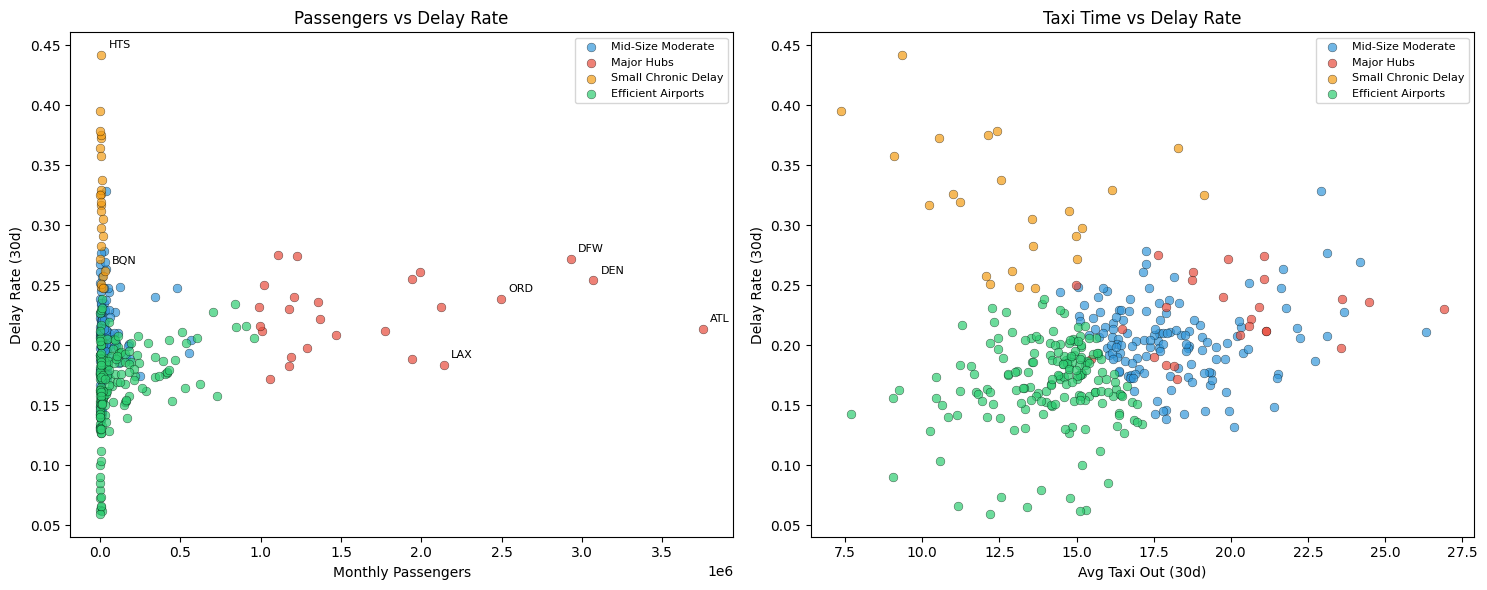

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

km_apt = KMeans(n_clusters=4, n_init=50, random_state=42)
airport_agg_clean['cluster'] = km_apt.fit_predict(X_apt)

colors = {0: '#3498db', 1: '#e74c3c', 2: '#f39c12', 3: '#2ecc71'}
names = {0: 'Mid-Size Moderate', 1: 'Major Hubs', 2: 'Small Chronic Delay', 3: 'Efficient Airports'}

for c in [0, 1, 2, 3]:
    subset = airport_agg_clean[airport_agg_clean['cluster'] == c]
    ax1.scatter(subset['origin_monthly_passengers'], subset['origin_delay_rate_30d'],
                c=colors[c], s=40, label=names[c], alpha=0.7, edgecolors='black', linewidth=0.3)
    ax2.scatter(subset['origin_avg_taxi_out_30d'], subset['origin_delay_rate_30d'],
                c=colors[c], s=40, label=names[c], alpha=0.7, edgecolors='black', linewidth=0.3)

for ap in ['ATL', 'DEN', 'DFW', 'ORD', 'LAX', 'BQN', 'HTS']:
    if ap in airport_agg_clean.index:
        row = airport_agg_clean.loc[ap]
        ax1.annotate(ap, (row['origin_monthly_passengers'], row['origin_delay_rate_30d']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)

ax1.set_xlabel('Monthly Passengers')
ax1.set_ylabel('Delay Rate (30d)')
ax1.set_title('Passengers vs Delay Rate')
ax1.legend(fontsize=8)

ax2.set_xlabel('Avg Taxi Out (30d)')
ax2.set_ylabel('Delay Rate (30d)')
ax2.set_title('Taxi Time vs Delay Rate')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [23]:
airport_cluster_names = {
    0: 'Mid-Size Moderate',
    1: 'Major Hubs',
    2: 'Small Chronic Delay',
    3: 'Efficient Airports'
}

airport_label_map = airport_agg_clean['cluster'].map(airport_cluster_names).to_dict()

flights['airport_cluster_label'] = flights['ORIGIN'].map(airport_label_map)

print(f"Nulls: {flights['airport_cluster_label'].isna().sum()}")
print(f"Null airports: {flights[flights['airport_cluster_label'].isna()]['ORIGIN'].unique()}")

print(f"\nDistribution:")
print(flights['airport_cluster_label'].value_counts())

print(f"\nDelay rate by cluster:")
print(flights.groupby('airport_cluster_label')['ARR_DEL15'].agg(['mean', 'count']).round(4).sort_values('mean', ascending=False))

Nulls: 2
Null airports: ['PHF']

Distribution:
airport_cluster_label
Major Hubs             10746214
Efficient Airports      5626964
Mid-Size Moderate       1819490
Small Chronic Delay       35126
Name: count, dtype: int64

Delay rate by cluster:
                         mean     count
airport_cluster_label                  
Small Chronic Delay    0.2991     35126
Major Hubs             0.2268  10746214
Mid-Size Moderate      0.2063   1819490
Efficient Airports     0.1869   5626964


In [24]:
flights.loc[flights['ORIGIN'] == 'PHF', 'airport_cluster_label'] = 'Small Chronic Delay'

print(f"Nulls: {flights['airport_cluster_label'].isna().sum()}")
print(f"Shape: {flights.shape}")

print(f"\n=== FULL VERIFICATION ===")
print(f"\nairline_cluster_label:")
print(f"  Nulls: {flights['airline_cluster_label'].isna().sum()}")
print(f"  Unique: {flights['airline_cluster_label'].nunique()}")
print(flights.groupby('airline_cluster_label')['ARR_DEL15'].agg(['mean','count']).round(4).sort_values('mean', ascending=False))

print(f"\nairport_cluster_label:")
print(f"  Nulls: {flights['airport_cluster_label'].isna().sum()}")
print(f"  Unique: {flights['airport_cluster_label'].nunique()}")
print(flights.groupby('airport_cluster_label')['ARR_DEL15'].agg(['mean','count']).round(4).sort_values('mean', ascending=False))

print(f"\nTotal rows: {len(flights):,} (expected 18,227,796)")
print(f"Total columns: {flights.shape[1]}")

Nulls: 0
Shape: (18227796, 120)

=== FULL VERIFICATION ===

airline_cluster_label:
  Nulls: 0
  Unique: 5
                                   mean    count
airline_cluster_label                           
Financially Stressed High Delay  0.2757  1809983
Financially Strong Operators     0.2140  8088286
Cascade Heavy Operations         0.2115  3938851
Mid-Tier Regionals               0.1969  3201058
Reliable Regionals               0.1526  1189618

airport_cluster_label:
  Nulls: 0
  Unique: 4
                         mean     count
airport_cluster_label                  
Small Chronic Delay    0.2991     35128
Major Hubs             0.2268  10746214
Mid-Size Moderate      0.2063   1819490
Efficient Airports     0.1869   5626964

Total rows: 18,227,796 (expected 18,227,796)
Total columns: 120


In [25]:
flights.to_parquet("dataset/merged_flights_fe.parquet", 
                   index=False, engine="pyarrow", compression="snappy")
import os
size_mb = os.path.getsize("dataset/merged_flights_fe.parquet") / 1024 / 1024
print(f"Saved. Size: {size_mb:.1f} MB | Shape: {flights.shape}")

Saved. Size: 1544.5 MB | Shape: (18227796, 120)


In [26]:
print("=" * 70)
print("STEP 4 FINAL AUDIT")
print("=" * 70)

print(f"\n1. SHAPE: {flights.shape}")
print(f"   Rows: {flights.shape[0]:,} (expected 18,227,796)")
print(f"   Cols: {flights.shape[1]} (was 97 before clustering, added 2)")

print(f"\n2. NEW COLUMNS:")
print(f"   airline_cluster_label: {flights['airline_cluster_label'].dtype}")
print(f"   airport_cluster_label: {flights['airport_cluster_label'].dtype}")

print(f"\n3. NULL CHECK:")
print(f"   airline_cluster_label nulls: {flights['airline_cluster_label'].isna().sum()}")
print(f"   airport_cluster_label nulls: {flights['airport_cluster_label'].isna().sum()}")

print(f"\n4. AIRLINE CLUSTERS — all 15 carriers mapped:")
print(flights.groupby(['airline_cluster_label', 'OP_UNIQUE_CARRIER']).size().reset_index(name='flights').to_string())

print(f"\n5. AIRPORT CLUSTERS — all 361 airports mapped:")
print(f"   Unique airports: {flights['ORIGIN'].nunique()}")
print(f"   Airports with labels: {flights.groupby('ORIGIN')['airport_cluster_label'].first().notna().sum()}")

print(f"\n6. DELAY RATE BY AIRLINE CLUSTER:")
print(flights.groupby('airline_cluster_label')['ARR_DEL15'].mean().round(4).sort_values(ascending=False).to_string())

print(f"\n7. DELAY RATE BY AIRPORT CLUSTER:")
print(flights.groupby('airport_cluster_label')['ARR_DEL15'].mean().round(4).sort_values(ascending=False).to_string())

print(f"\n8. DUPLICATE CHECK:")
print(f"   Duplicate rows: {flights.duplicated().sum()}")

print(f"\n9. TARGET INTACT:")
print(f"   ARR_DEL15 value counts:")
print(flights['ARR_DEL15'].value_counts())

print(f"\n10. ALL {flights.shape[1]} COLUMNS:")
for i, col in enumerate(flights.columns):
    print(f"    {i+1:3d}. {col}")

STEP 4 FINAL AUDIT

1. SHAPE: (18227796, 120)
   Rows: 18,227,796 (expected 18,227,796)
   Cols: 120 (was 97 before clustering, added 2)

2. NEW COLUMNS:
   airline_cluster_label: object
   airport_cluster_label: object

3. NULL CHECK:
   airline_cluster_label nulls: 0
   airport_cluster_label nulls: 0

4. AIRLINE CLUSTERS — all 15 carriers mapped:
              airline_cluster_label OP_UNIQUE_CARRIER  flights
0          Cascade Heavy Operations                HA   210025
1          Cascade Heavy Operations                WN  3728826
2   Financially Stressed High Delay                B6   654301
3   Financially Stressed High Delay                F9   504061
4   Financially Stressed High Delay                NK   651621
5      Financially Strong Operators                AA  2520340
6      Financially Strong Operators                AS   641236
7      Financially Strong Operators                DL  2632944
8      Financially Strong Operators                G4   319584
9      Financially 

In [27]:
print(f"Duplicate rows: {flights.duplicated().sum()}")

print(f"\nTARGET INTACT:")
print(flights['ARR_DEL15'].value_counts())

print(f"\nFile saved check:")
import os
size_mb = os.path.getsize("dataset/merged_flights_fe.parquet") / 1024 / 1024
print(f"Size: {size_mb:.1f} MB")

Duplicate rows: 0

TARGET INTACT:
ARR_DEL15
0.0    14353289
1.0     3874507
Name: count, dtype: int64

File saved check:
Size: 1544.5 MB


In [28]:
verify = pd.read_parquet("dataset/merged_flights_fe.parquet")

print(f"Shape in memory:  {flights.shape}")
print(f"Shape from disk:  {verify.shape}")
print(f"Match: {flights.shape == verify.shape}")

print(f"\n=== Cluster columns saved correctly ===")
print(f"airline_cluster_label in file: {'airline_cluster_label' in verify.columns}")
print(f"airport_cluster_label in file: {'airport_cluster_label' in verify.columns}")

print(f"\nairline_cluster_label from disk:")
print(verify['airline_cluster_label'].value_counts())

print(f"\nairport_cluster_label from disk:")
print(verify['airport_cluster_label'].value_counts())

print(f"\nNulls from disk:")
print(f"  airline: {verify['airline_cluster_label'].isna().sum()}")
print(f"  airport: {verify['airport_cluster_label'].isna().sum()}")

print(f"\nTarget from disk:")
print(verify['ARR_DEL15'].value_counts())

del verify 

Shape in memory:  (18227796, 120)
Shape from disk:  (18227796, 120)
Match: True

=== Cluster columns saved correctly ===
airline_cluster_label in file: True
airport_cluster_label in file: True

airline_cluster_label from disk:
airline_cluster_label
Financially Strong Operators       8088286
Cascade Heavy Operations           3938851
Mid-Tier Regionals                 3201058
Financially Stressed High Delay    1809983
Reliable Regionals                 1189618
Name: count, dtype: int64

airport_cluster_label from disk:
airport_cluster_label
Major Hubs             10746214
Efficient Airports      5626964
Mid-Size Moderate       1819490
Small Chronic Delay       35128
Name: count, dtype: int64

Nulls from disk:
  airline: 0
  airport: 0

Target from disk:
ARR_DEL15
0.0    14353289
1.0     3874507
Name: count, dtype: int64


In [29]:
# Add airline_cluster_label to main merged_flights.parquet
import pandas as pd

main = pd.read_parquet('dataset/merged_flights.parquet')
main['airline_cluster_label'] = main['OP_UNIQUE_CARRIER'].map(airline_label_map)
main['airline_cluster_label'] = main['airline_cluster_label'].replace(
    {'High Delay Regionals': 'Mid-Tier Regionals'}
)

print(f"Cluster distribution:")
print(main['airline_cluster_label'].value_counts())
print(f"Nulls: {main['airline_cluster_label'].isna().sum()}")

main.to_parquet('dataset/merged_flights.parquet', index=False)
print(f"Saved: {main.shape}")

Cluster distribution:
airline_cluster_label
Financially Strong Operators       8088286
Cascade Heavy Operations           3938851
Mid-Tier Regionals                 3201058
Financially Stressed High Delay    1809983
Reliable Regionals                 1189618
Name: count, dtype: int64
Nulls: 0
Saved: (18227796, 78)
